In [ ]:
import sys
sys.path.append(os.getcwd().replace("\\", "/"))

from Augmentation import (Noise_aug, filter_short_sequences, split_long_seq, GP_aug,
prepare_sequence, AvgPair_segments, ChannelDrop_aug, TimeShift_aug, TimeMask_aug, cap_long_seq,
Noise_aug_with_shift, Scale_aug)

# Applying Gaussian Process

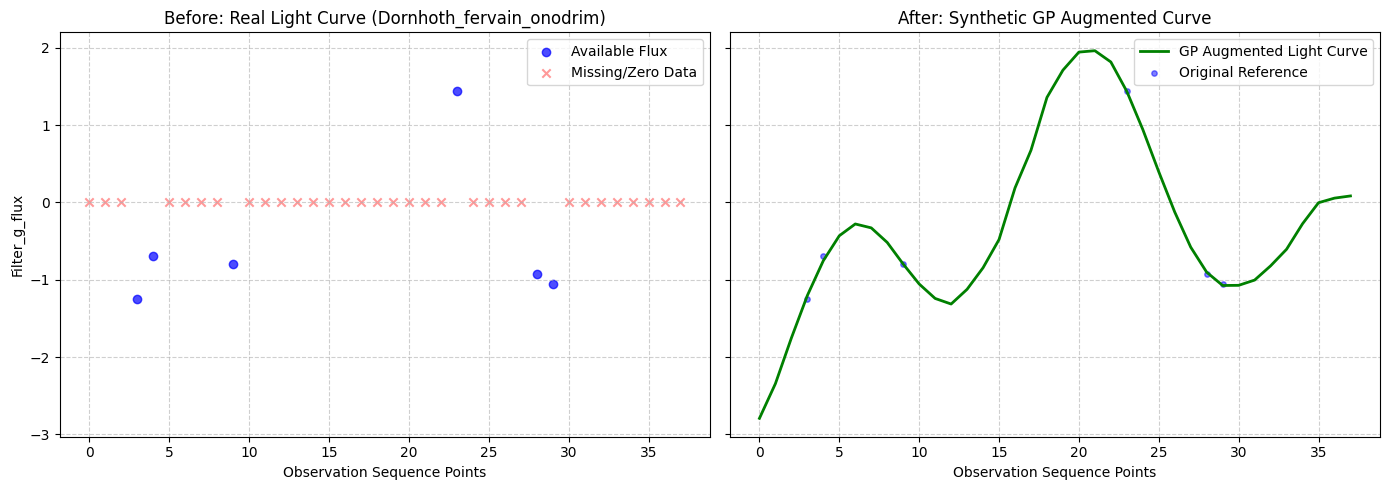

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
import pandas as pd
from pathlib import Path

# ==========================================
# 1. GP Augmentation Function
# ==========================================
def gp_multichannel_time_series_augment(X, y, n_aug=1, random_state=42, balance=False):
    rng = np.random.default_rng(random_state)
    N, T, C = X.shape
    X_new = []
    y_new = []

    kernel = RBF(length_scale=0.15, length_scale_bounds="fixed") + \
             WhiteKernel(noise_level=1e-3, noise_level_bounds="fixed")

    t_all = (np.arange(T) / T).reshape(-1, 1)

    for i in range(N):
        if balance and (y[i] != 1):
            continue
        x_orig = X[i]
        for _ in range(n_aug):
            x_syn = np.zeros_like(x_orig)
            for ch in range(C):
                flux = x_orig[:, ch]
                valid_idx = np.where(flux != 0)[0]
                if len(valid_idx) < 2:
                    continue
                t_valid = (valid_idx / T).reshape(-1, 1)
                y_valid = flux[valid_idx]
                gp = GaussianProcessRegressor(kernel=kernel, random_state=random_state, n_restarts_optimizer=0)
                gp.fit(t_valid, y_valid)
                pred, std = gp.predict(t_all, return_std=True)
                noise = rng.normal(0, 0.15 * std)
                x_syn[:, ch] = pred + noise
            X_new.append(x_syn)
            y_new.append(y[i])

    return np.stack(X_new), np.array(y_new)

# ==========================================
# 2. Extract Real CSV Sequence Data
# ==========================================
import os
location_of_file = f'{os.getcwd().replace("\\", "/")}/Data/Processed Data'

df = pd.read_csv(f"{location_of_file}/total_df.csv")
sequence = df[df["object_id"] == "Dornhoth_fervain_onodrim"][["Time (MJD)", "Filter_g_flux"]]
real_flux = sequence["Filter_g_flux"].to_numpy()

# Important: If your dataset represents gaps as NaNs, change them to 0 
# because your GP function looks specifically for 'flux != 0'
real_flux = np.nan_to_num(real_flux, nan=0.0)

# Get the length of this specific sequence
T = len(real_flux)  
C = 1               # 1 channel (Filter_g_flux)
N = 1               # 1 sample object

# Reshape the real sequence to match (N, T, C)
X_train = real_flux.reshape(N, T, C)
y_train = np.array([1])  # Dummy target label for this object

# ==========================================
# 3. Run the Augmentation Function
# ==========================================
X_aug, y_aug = gp_multichannel_time_series_augment(X_train, y_train, n_aug=1, random_state=42, balance=False)

# Extract 1D arrays for plotting
t_steps = np.arange(T)
# If you want to plot using actual MJD instead of step index, use:
# t_steps = sequence["Time (MJD)"].to_numpy()

original_curve = X_train[0, :, 0]
augmented_curve = X_aug[0, :, 0]

# ==========================================
# 4. Plot "Before" and "After" side-by-side
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot Before
valid_mask = original_curve != 0
axes[0].scatter(t_steps[valid_mask], original_curve[valid_mask], color='blue', label='Available Flux', alpha=0.7)
axes[0].scatter(t_steps[~valid_mask], original_curve[~valid_mask], color='red', marker='x', label='Missing/Zero Data', alpha=0.4)
axes[0].set_title("Before: Real Light Curve (Dornhoth_fervain_onodrim)")
axes[0].set_xlabel("Observation Sequence Points")
axes[0].set_ylabel("Filter_g_flux")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot After
axes[1].plot(t_steps, augmented_curve, color='green', linewidth=2, label='GP Augmented Light Curve')
axes[1].scatter(t_steps[valid_mask], original_curve[valid_mask], color='blue', s=15, label='Original Reference', alpha=0.5)
axes[1].set_title("After: Synthetic GP Augmented Curve")
axes[1].set_xlabel("Observation Sequence Points")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
directory = "D:/Senior Project/Mallorn version 2/Results/Plots"
plt.savefig(f'{directory}/Gaussian_augmentation_curve.png', bbox_inches='tight', dpi=300)
plt.show()

# Succesive pair Augmentation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def AvgPair_aug(X, y=None, n_aug=1, balance=False):
    X_new, y_new = [], []

    for i in range(X.shape[0]):
        if balance and y is not None and y[i] != 1:
            continue

        x = X[i].astype(np.float32)

        for _ in range(n_aug):
            x_aug = np.zeros_like(x)

            for ch in range(x.shape[1]):
                nz_idx = np.where(x[:, ch] != 0)[0]

                if len(nz_idx) == 0:
                    continue

                splits = np.where(np.diff(nz_idx) != 1)[0] + 1
                segments = np.split(nz_idx, splits)

                for seg in segments:
                    if len(seg) < 2:
                        continue

                    for k in range(1, len(seg)):
                        t = seg[k]
                        t_prev = seg[k - 1]
                        x_aug[t, ch] = 0.5 * (x[t_prev, ch] + x[t, ch])

            X_new.append(x_aug)

            if y is not None:
                y_new.append(y[i])

    return np.stack(X_new), np.array(y_new)


# --- 1. Create Gaussian sparse signal ---
t = np.arange(100)
gaussian_base = 25 * np.exp(-(t - 50)**2 / (2 * 10**2))

np.random.seed(42)
mask = np.random.choice([0, 1], size=100, p=[0.7, 0.3])
sparse_data = (gaussian_base * mask).reshape(1, 100, 1)

dummy_y = np.array([1])

# --- 2. Apply augmentation ---
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Apply augmentation ---
X_aug, _ = AvgPair_aug(sparse_data, dummy_y)

orig = sparse_data[0, :, 0]
aug = X_aug[0, :, 0]

t = np.arange(len(orig))

# --- 2. Mask zeros (replace with NaN so they are not plotted) ---
orig_plot = orig.copy()
aug_plot = aug.copy()

orig_plot[orig_plot == 0] = np.nan
aug_plot[aug_plot == 0] = np.nan

# --- 3. Plot ---
plt.figure(figsize=(10, 6))

plt.scatter(t, orig_plot, label="Before (sparse)", alpha=0.7)
plt.scatter(t, aug_plot, label="After (segment smoothing)", linewidth=2)

plt.plot(t, gaussian_base, '--', color='gray', alpha=0.4, label="Underlying Gaussian")

plt.title("Effect of Successive Flux Smoothing on Sparse Signal")
plt.xlabel("Time Steps")
plt.ylabel("Flux Intensity")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

# Time shift Augmentation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Apply time shift augmentation ---
X_shift, _ = TimeShift_aug(sparse_data, dummy_y, n_aug=1)

orig = sparse_data[0, :, 0]
shifted = X_shift[0, :, 0]

t = np.arange(len(orig))

# --- Remove zeros from plot (treat as missing) ---
orig_plot = orig.copy()
shift_plot = shifted.copy()

orig_plot[orig_plot == 0] = np.nan
shift_plot[shift_plot == 0] = np.nan

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.scatter(t, orig_plot, label="Before (sparse)", alpha=0.7)
plt.scatter(t, shift_plot, label="After (time shift)", linewidth=2)

plt.plot(t, gaussian_base, '--', color='gray', alpha=0.4, label="Underlying Gaussian")

plt.title("Effect of Time Shift Augmentation on Sparse Signal")
plt.xlabel("Time Steps")
plt.ylabel("Flux Intensity")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

# Noise Shift

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Apply augmentation ---
X_aug, _ = Noise_aug_with_shift(sparse_data, dummy_y, n_aug=1)

orig = sparse_data[0, :, 0]
aug = X_aug[0, :, 0]

t = np.arange(len(orig))

# --- Remove zeros from plotting ---
orig_plot = orig.copy()
aug_plot = aug.copy()

orig_plot[orig_plot == 0] = np.nan
aug_plot[aug_plot == 0] = np.nan

# --- Plot ---
plt.figure(figsize=(10, 6))

plt.scatter(t, orig_plot, label="Before (sparse)", alpha=0.7)
plt.scatter(t, aug_plot, label="After (shift)", linewidth=2)

plt.title("Effect of Flux Shift Augmentation on Sparse Signal")
plt.xlabel("Time Steps")
plt.ylabel("Flux Intensity")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()